In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
from functions import dL_rosenbrock_1d
from src.optimizer import AdamScratch1D, NonlocalSolverMomentumAdam
from src.utils import AdamPlotter
import matplotlib.pyplot as plt
import numpy as np

# CONDITIONS

In [3]:
a = 1
lr = 0.001
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
epochs = int(1e4)
initial_theta = 5.0

# DISCRETE-ADAM

In [4]:

optimizer = AdamScratch1D(
    dL = dL_rosenbrock_1d,
    lr=lr,
    beta1=beta1,
    beta2=beta2,
    epsilon=epsilon,
    epochs=epochs
)

theta_history, m_history, v_history, iterations = optimizer.solve(
    theta_initial=initial_theta,
    function_parameters=(a,)
    )

print(f"Valor final de theta: {theta_history[-1]}")


Epoch: 50, theta=4.950184e+00, Error: 9.904697e-04
Epoch: 100, theta=4.901034e+00, Error: 9.757909e-04
Epoch: 150, theta=4.852614e+00, Error: 9.613651e-04
Epoch: 200, theta=4.804905e+00, Error: 9.473321e-04
Epoch: 250, theta=4.757888e+00, Error: 9.336783e-04
Epoch: 300, theta=4.711545e+00, Error: 9.203896e-04
Epoch: 350, theta=4.665857e+00, Error: 9.074529e-04
Epoch: 400, theta=4.620807e+00, Error: 8.948554e-04
Epoch: 450, theta=4.576378e+00, Error: 8.825850e-04
Epoch: 500, theta=4.532555e+00, Error: 8.706300e-04
Epoch: 550, theta=4.489322e+00, Error: 8.589792e-04
Epoch: 600, theta=4.446664e+00, Error: 8.476221e-04
Epoch: 650, theta=4.404566e+00, Error: 8.365482e-04
Epoch: 700, theta=4.363015e+00, Error: 8.257477e-04
Epoch: 750, theta=4.321998e+00, Error: 8.152110e-04
Epoch: 800, theta=4.281500e+00, Error: 8.049292e-04
Epoch: 850, theta=4.241511e+00, Error: 7.948933e-04
Epoch: 900, theta=4.202017e+00, Error: 7.850951e-04
Epoch: 950, theta=4.163007e+00, Error: 7.755262e-04
Epoch: 1000, 

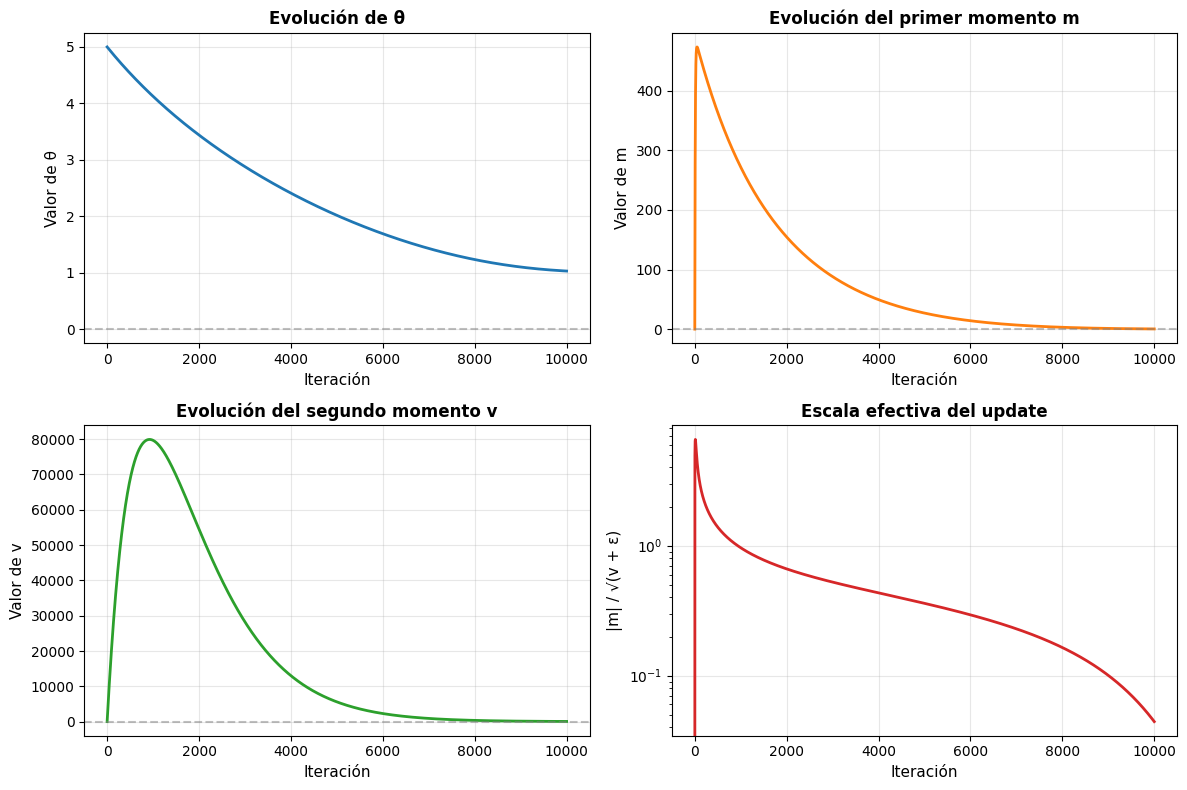

In [5]:
# Crear el plotter y visualizar
plotter = AdamPlotter(theta_history, m_history, v_history)

# Plotear todo
plotter.plot('all')
plt.show()

# CONTINUOUS ADAM

In [6]:
def dL_wrapper(theta):
    return dL_rosenbrock_1d(theta, (a,))

In [ ]:
print("Resolviendo theta1...")
optimizer_theta = NonlocalSolverMomentumAdam(
    dL=dL_wrapper,
    t_span=(lr, 10.0),
    y0=[initial_theta, 0.0],
    alpha=lr,
    betas=(beta1, beta2),
    eps_base=epsilon,
    verbose=True,
    quad_order=50
)
t, y = optimizer_theta.solve()

theta_history = y[:, 0]
theta_dot_history = y[:, 1]
final_state = theta_history[-1]
if isinstance(final_state, np.ndarray) and final_state.size > 1:
    # Ecuación de 2do orden
    print(f"\nValor final de theta: {final_state[0]:.6e}")
    print(f"Velocidad final: {final_state[1]:.6e}")
else:
    # Ecuación de 1er orden (escalar)
    print(f"\nValor final de theta: {float(final_state):.6e}")

print(f"Tiempo final: {t[-1]}")
print(f"Número de pasos: {len(t)}")

Resolviendo theta1...
Second order equation --> using sinh/sin kernels
ParallelComputation: joblib backend='loky', workers=23/24

Building functional RHS (iteration 0)...
¿No finitos en y?: False (NaN: False, Inf: False)

--- DEBUG interpolador ---
y_pos shape: (200,), dtype: float64
y_pos[:5]: [5. 5. 5. 5. 5.]
y_pos finitos: True
--- FIN DEBUG ---

Computing moments for 200 time points...
  Parallel execution: 200 items → 23 workers (joblib/loky)
Moments computed in 0.17s
m[0]=4.880e+02, v[0]=2.235e+04
m[1]=4.880e+02, v[1]=2.257e+04
m[-1]=4.880e+02, v[-1]=6.131e+04

Building functional RHS (iteration 0)...
¿No finitos en y?: False (NaN: False, Inf: False)

--- DEBUG interpolador ---
y_pos shape: (200,), dtype: float64
y_pos[:5]: [5.         5.         5.02014423 5.10071963 5.36258708]
y_pos finitos: True
--- FIN DEBUG ---

Computing moments for 200 time points...
  Parallel execution: 200 items → 23 workers (joblib/loky)


/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optim


200 problemas detectados en momentos:
t=1.000000: m=-6.075e+07, v=7.346e+20, g(t)=4.880e+02
t=1.010000: m=-5.466e+07, v=7.339e+20, g(t)=4.880e+02
t=1.020000: m=-4.919e+07, v=7.332e+20, g(t)=4.940e+02
t=1.030000: m=-4.426e+07, v=7.324e+20, g(t)=5.186e+02
t=1.040000: m=-3.982e+07, v=7.317e+20, g(t)=6.041e+02
... y 195 más
Moments computed in 0.18s
m[0]=-6.075e+07, v[0]=7.346e+20
m[1]=-5.466e+07, v[1]=7.339e+20
m[-1]=4.235e+276, v[-1]=inf
Iter 0 – err 9.464557933101785e+94

Building functional RHS (iteration 1)...
¿No finitos en y?: False (NaN: False, Inf: False)

--- DEBUG interpolador ---
y_pos shape: (200,), dtype: float64
y_pos[:5]: [5.         5.         5.0100652  5.0503259  5.18117295]
y_pos finitos: True
--- FIN DEBUG ---

Computing moments for 200 time points...
  Parallel execution: 200 items → 23 workers (joblib/loky)

200 problemas detectados en momentos:
t=1.000000: m=-7.496e+06, v=1.135e+19, g(t)=4.880e+02
t=1.010000: m=-6.745e+06, v=1.133e+19, g(t)=4.880e+02
t=1.020000: m=

/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optim


200 problemas detectados en momentos:
t=1.000000: m=-9.132e+05, v=1.732e+17, g(t)=4.880e+02
t=1.010000: m=-8.217e+05, v=1.730e+17, g(t)=4.880e+02
t=1.020000: m=-7.393e+05, v=1.728e+17, g(t)=4.895e+02
t=1.030000: m=-6.652e+05, v=1.727e+17, g(t)=4.955e+02
t=1.040000: m=-5.985e+05, v=1.725e+17, g(t)=5.155e+02
... y 195 más
Moments computed in 0.16s
m[0]=-9.132e+05, v[0]=1.732e+17
m[1]=-8.217e+05, v[1]=1.730e+17
m[-1]=6.578e+274, v[-1]=inf
Iter    2 │ err=2.366031e+94 │ smooth=0.5000

Building functional RHS (iteration 3)...
¿No finitos en y?: False (NaN: False, Inf: False)

--- DEBUG interpolador ---
y_pos shape: (200,), dtype: float64
y_pos[:5]: [5.         5.         5.00250609 5.01253142 5.0451153 ]
y_pos finitos: True
--- FIN DEBUG ---

Computing moments for 200 time points...
  Parallel execution: 200 items → 23 workers (joblib/loky)

200 problemas detectados en momentos:
t=1.000000: m=-1.083e+05, v=2.583e+15, g(t)=4.880e+02
t=1.010000: m=-9.739e+04, v=2.580e+15, g(t)=4.880e+02
t=1.

...

/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optim


186 problemas detectados en momentos:
t=1.140000: m=1.189e+06, v=3.715e+11, g(t)=1.006e+08
t=1.150000: m=3.008e+07, v=2.457e+14, g(t)=2.626e+09
t=1.160000: m=7.948e+08, v=1.736e+17, g(t)=7.008e+10
t=1.170000: m=2.131e+10, v=1.252e+20, g(t)=1.885e+12
t=1.180000: m=5.739e+11, v=9.097e+22, g(t)=5.083e+13
... y 181 más
Moments computed in 0.17s
m[0]=3.873e+02, v[0]=1.105e+09
m[1]=3.973e+02, v[1]=1.104e+09
m[-1]=7.241e+270, v[-1]=inf
Iter  208 │ err=7.883154e+92 │ smooth=0.5240

Building functional RHS (iteration 209)...
¿No finitos en y?: False (NaN: False, Inf: False)

--- DEBUG interpolador ---
y_pos shape: (200,), dtype: float64
y_pos[:5]: [5.         5.         5.00015933 5.00080002 5.0028879 ]
y_pos finitos: True
--- FIN DEBUG ---

Computing moments for 200 time points...
  Parallel execution: 200 items → 23 workers (joblib/loky)

186 problemas detectados en momentos:
t=1.140000: m=3.724e+05, v=3.543e+10, g(t)=3.080e+07
t=1.150000: m=9.122e+06, v=2.240e+13, g(t)=7.902e+08
t=1.160000:

/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optim


186 problemas detectados en momentos:
t=1.140000: m=1.189e+06, v=3.715e+11, g(t)=1.006e+08
t=1.150000: m=3.008e+07, v=2.457e+14, g(t)=2.626e+09
t=1.160000: m=7.948e+08, v=1.736e+17, g(t)=7.008e+10
t=1.170000: m=2.131e+10, v=1.252e+20, g(t)=1.885e+12
t=1.180000: m=5.739e+11, v=9.097e+22, g(t)=5.083e+13
... y 181 más
Moments computed in 0.19s
m[0]=3.873e+02, v[0]=1.105e+09
m[1]=3.973e+02, v[1]=1.104e+09
m[-1]=7.241e+270, v[-1]=inf
Iter  210 │ err=7.883154e+92 │ smooth=0.5240

Building functional RHS (iteration 211)...
¿No finitos en y?: False (NaN: False, Inf: False)

--- DEBUG interpolador ---
y_pos shape: (200,), dtype: float64
y_pos[:5]: [5.         5.         5.00015933 5.00080002 5.0028879 ]
y_pos finitos: True
--- FIN DEBUG ---

Computing moments for 200 time points...
  Parallel execution: 200 items → 23 workers (joblib/loky)

186 problemas detectados en momentos:
t=1.140000: m=3.724e+05, v=3.543e+10, g(t)=3.080e+07
t=1.150000: m=9.122e+06, v=2.240e+13, g(t)=7.902e+08
t=1.160000:

/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/nonlocal_adam_solver.py:164: RuntimeWarning: overflow encountered in square
  f_v = lambda tau: self.K2(t - tau) * g_fun(tau)**2
/home/thebigmonster/Github/nonlocal-adam-type/src/optim

/home/thebigmonster/Github/nonlocal-adam-type/src/utils/ploting.py:105: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[1, 1].set_yscale('log')


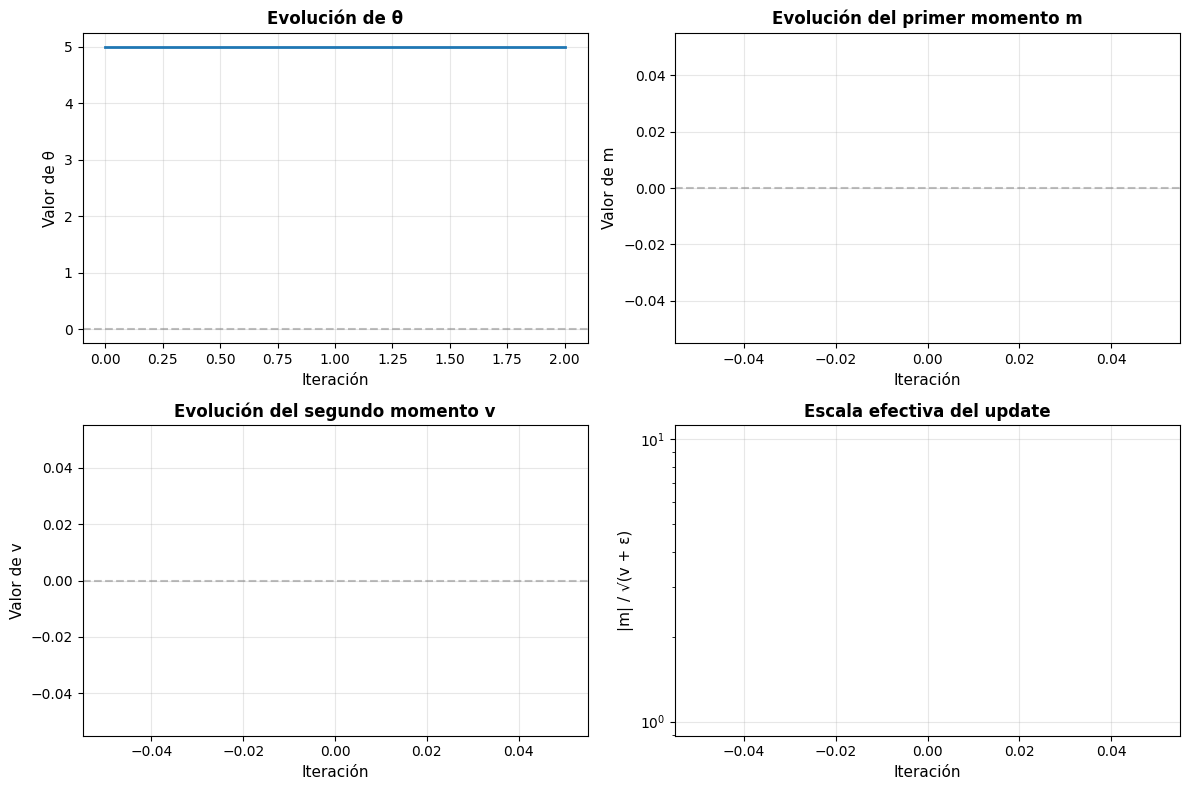

In [8]:
# Crear el plotter y visualizar
plotter = AdamPlotter(theta_history, optimizer_theta._last_m[:, 1], optimizer_theta._last_v[:, 1])

# Plotear todo
plotter.plot('all')
plt.show()